In [54]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "HeartDiseaseTrain-Test.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ketangangal/heart-disease-dataset-uci",
  file_path,
)


Using Colab cache for faster access to the 'heart-disease-dataset-uci' dataset.


In [55]:
df.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [56]:
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt
import warnings
import networkx as nx
warnings.filterwarnings('ignore')

In [57]:
def make_factor(variables, cardinalities, values=None):
    size = int(np.prod(cardinalities))
    val = np.zeros(size) if values is None else np.array(values, dtype=float)

    return {
        "var": list(variables),
        "card": list(cardinalities),
        "val": val
    }

In [58]:
def normalize_factor(F):
    s = F["val"].sum()
    G = copy.deepcopy(F)
    if s > 0:
        G["val"] = G["val"] / s
    return G

def query_disease(I, evidence):
    factors = [copy.deepcopy(f) for f in I["RandomFactors"]]
    for v, val in evidence.items():
        factors = [observe(f, v, val) for f in factors]
    joint = factors[0]
    for f in factors[1:]:
        joint = factor_product(joint, f)
    for v in [1, 2, 3, 4]:
        joint = factor_marginalize(joint, v)
    return normalize_factor(joint)


In [59]:
def idx_to_assign(idx, cards):
    assign = []

    for c in reversed(cards):
        assign.append(idx % c)
        idx //= c

    return list(reversed(assign))

def assign_to_idx(assign, cards):
    idx = 0
    stride = 1

    for i in range(len(assign)-1, -1, -1):
        idx += assign[i] * stride
        stride *= cards[i]

    return idx

In [60]:
def factor_product(A, B):
    if not A["var"]:
        return B
    if not B["var"]:
        return A

    all_vars = list(dict.fromkeys(A["var"] + B["var"]))

    card_map = {v:c for v,c in zip(A["var"],A["card"])}
    card_map.update({v:c for v,c in zip(B["var"],B["card"])})

    all_cards = [card_map[v] for v in all_vars]

    C = make_factor(all_vars, all_cards)

    for i in range(len(C["val"])):
        assignment = idx_to_assign(i, all_cards)

        amap = {v:assignment[j] for j,v in enumerate(all_vars)}

        ia = assign_to_idx([amap[v] for v in A["var"]], A["card"])
        ib = assign_to_idx([amap[v] for v in B["var"]], B["card"])

        C["val"][i] = A["val"][ia] * B["val"][ib]

    return C

def factor_sum(A, B):
    C = copy.deepcopy(A)
    C["val"] = A["val"] + B["val"]
    return C


def factor_marginalize(F, var):
    if var not in F["var"]:
        return F

    idx = F["var"].index(var)

    new_vars = [v for v in F["var"] if v != var]
    new_cards = [c for i,c in enumerate(F["card"]) if i != idx]

    G = make_factor(new_vars, new_cards if new_cards else [1])

    for i in range(len(F["val"])):
        assignment = idx_to_assign(i, F["card"])

        new_assignment = [assignment[j] for j in range(len(assignment)) if j != idx]

        gi = assign_to_idx(new_assignment, new_cards) if new_cards else 0

        G["val"][gi] += F["val"][i]

    return G

In [61]:
def observe(F, var, val):
    if var not in F["var"]:
        return F

    G = copy.deepcopy(F)
    idx = G["var"].index(var)

    for i in range(len(G["val"])):
        assignment = idx_to_assign(i, G["card"])
        if assignment[idx] != val:
            G["val"][i] = 0

    return G

In [62]:
def calculate_euf(I):
    joint = None

    for rf in I["RandomFactors"]:
        joint = rf if joint is None else factor_product(joint, rf)

    euf = factor_product(joint, I["UtilityFactors"][0])

    decision_vars = set()
    for d in I["DecisionFactors"]:
        decision_vars.update(d["var"])

    for v in list(euf["var"]):
        if v not in decision_vars:
            euf = factor_marginalize(euf, v)

    return euf


def optimize_meu(I):
    D = I["DecisionFactors"][0]
    euf = calculate_euf(I)

    opt = copy.deepcopy(D)
    opt["val"] = np.zeros(len(D["val"]))

    best = np.argmax(euf["val"])
    opt["val"][best] = 1

    return euf["val"][best], opt


def optimize_meu_evidence(I, evidence):
    I2 = copy.deepcopy(I)

    for v,val in evidence.items():
        I2["RandomFactors"] = [
            observe(f, v, val) for f in I2["RandomFactors"]
        ]

    return optimize_meu(I2)

In [63]:
def evpi(I):
    meu_base, _ = optimize_meu(I)
    D_factor = query_disease(I, evidence={})
    p_no_disease = D_factor["val"][0]
    p_disease    = D_factor["val"][1]

    U = I["UtilityFactors"][0]
    eu_if_know_no  = max(U["val"][assign_to_idx([0,0],[2,2])],
                         U["val"][assign_to_idx([0,1],[2,2])])
    eu_if_know_yes = max(U["val"][assign_to_idx([1,0],[2,2])],
                         U["val"][assign_to_idx([1,1],[2,2])])

    meu_perfect = p_no_disease * eu_if_know_no + p_disease * eu_if_know_yes
    return max(0, meu_perfect - meu_base)

- 0 = D (Disease)
- 1 = C (Chol)
- 2 = E (Exang)
- 3 = A (Age)
- 4 = H (Heart rate)
- 5 = S (Decision)

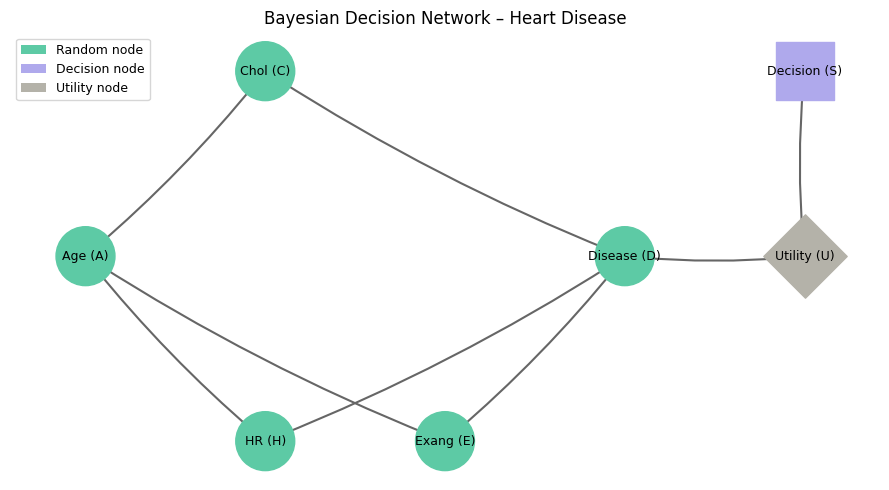

In [64]:
# DAG visualization

def draw_dag():
    G = nx.DiGraph()
    nodes = {
        "Age (A)":      {"type": "random"},
        "Chol (C)":     {"type": "random"},
        "HR (H)":       {"type": "random"},
        "Exang (E)":    {"type": "random"},
        "Disease (D)":  {"type": "random"},
        "Decision (S)": {"type": "decision"},
        "Utility (U)":  {"type": "utility"},
    }
    edges = [
        ("Age (A)",     "Chol (C)"),
        ("Age (A)",     "HR (H)"),
        ("Age (A)",     "Exang (E)"),
        ("Chol (C)",    "Disease (D)"),
        ("HR (H)",      "Disease (D)"),
        ("Exang (E)",   "Disease (D)"),
        ("Disease (D)", "Utility (U)"),
        ("Decision (S)","Utility (U)"),
    ]
    G.add_nodes_from(nodes.keys())
    G.add_edges_from(edges)

    pos = {
        "Age (A)":      (0,   1),
        "Chol (C)":     (1,   2),
        "HR (H)":       (1,   0),
        "Exang (E)":    (2,   0),
        "Disease (D)":  (3,   1),
        "Decision (S)": (4,   2),
        "Utility (U)":  (4,   1),
    }

    fig, ax = plt.subplots(figsize=(9, 5))
    color_map = {
        "random":   "#5DCAA5",
        "decision": "#AFA9EC",
        "utility":  "#B4B2A9",
    }
    colors = [color_map[nodes[n]["type"]] for n in G.nodes()]
    shapes = {"random": "o", "decision": "s", "utility": "D"}

    for ntype, shape in shapes.items():
        ns = [n for n in G.nodes() if nodes[n]["type"] == ntype]
        nc = [color_map[ntype]] * len(ns)
        nx.draw_networkx_nodes(G, pos, nodelist=ns, node_shape=shape,
                               node_color=nc, node_size=1800, ax=ax)

    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="500", ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20,
                           edge_color="#666", width=1.5,
                           connectionstyle="arc3,rad=0.05", ax=ax)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#5DCAA5", label="Random node"),
        Patch(facecolor="#AFA9EC", label="Decision node"),
        Patch(facecolor="#B4B2A9", label="Utility node"),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
    ax.set_title("Bayesian Decision Network – Heart Disease", fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("dag_heart.png", dpi=150, bbox_inches="tight")
    plt.show()

draw_dag()

In [65]:
def discretize(df):

    df = df.copy()

    df["age_bin"] = pd.cut(df["age"], [0,40,55,100], labels=[0,1,2]).astype(int)

    df["chol_bin"] = pd.cut(df["cholestoral"], [0,200,240,1000],
                            labels=[0,1,2]).astype(int)

    df["hr_bin"] = pd.cut(df["Max_heart_rate"], [0,120,160,250],
                         labels=[0,1,2]).astype(int)

    df["exang_bin"] = (df["exercise_induced_angina"] == "Yes").astype(int)

    df["target"] = df["target"].astype(int)

    return df

In [66]:
df = discretize(df)
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target,age_bin,chol_bin,hr_bin,exang_bin
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0,1,1,2,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0,1,1,1,1
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0,2,0,1,1
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0,2,1,2,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0,2,2,0,0


In [67]:
A = make_factor([3], [3])

counts = df["age_bin"].value_counts().sort_index()
A["val"] = (counts.values + 1e-3) / (counts.values + 1e-3).sum()

In [68]:
C = make_factor([1,3], [3,3])  # C | A

for a in range(3):
    sub = df[df["age_bin"] == a]
    total = len(sub) + 3*1e-3

    for c in range(3):
        count = (sub["chol_bin"] == c).sum() + 1e-3
        idx = assign_to_idx([c,a],[3,3])
        C["val"][idx] = count / total

In [69]:
H = make_factor([4,1], [3,3])  # H | C

for c in range(3):
    sub = df[df["chol_bin"] == c]
    total = len(sub) + 3*1e-3

    for h in range(3):
        count = (sub["hr_bin"] == h).sum() + 1e-3
        idx = assign_to_idx([h,c],[3,3])
        H["val"][idx] = count / total

In [70]:
E = make_factor([2,3], [2,3])  # E | A

for a in range(3):
    sub = df[df["age_bin"] == a]
    total = len(sub) + 2*1e-3

    for e in range(2):
        count = (sub["exang_bin"] == e).sum() + 1e-3
        idx = assign_to_idx([e,a],[2,3])
        E["val"][idx] = count / total

In [71]:
D = make_factor([0,1,4,2], [2,3,3,2])  # D | C,H,E

eps = 1e-3

for c in range(3):
    for h in range(3):
        for e in range(2):

            sub = df[
                (df["chol_bin"]==c) &
                (df["hr_bin"]==h) &
                (df["exang_bin"]==e)
            ]

            total = len(sub) + 2*eps
            p1 = (sub["target"].sum() + eps) / total
            p0 = 1 - p1

            i0 = assign_to_idx([0,c,h,e],[2,3,3,2])
            i1 = assign_to_idx([1,c,h,e],[2,3,3,2])

            D["val"][i0] = p0
            D["val"][i1] = p1

In [72]:
S = make_factor([5], [2], [0.5, 0.5])

U = make_factor([0,5], [2,2])
U["val"][assign_to_idx([0,0],[2,2])] = 10
U["val"][assign_to_idx([0,1],[2,2])] = -20
U["val"][assign_to_idx([1,0],[2,2])] = -100
U["val"][assign_to_idx([1,1],[2,2])] = 80

In [73]:
I = {
    "RandomFactors": [A, C, H, E, D],
    "DecisionFactors": [S],
    "UtilityFactors": [U]
}

In [74]:
euf = calculate_euf(I)

best = np.argmax(euf["val"])
print("EU No Test:", euf["val"][0])
print("EU Test   :", euf["val"][1])
print("Optimal   :", "Test" if euf["val"][1] > euf["val"][0] else "No Test")

EU No Test: -45.38081182253087
EU Test   : 30.346192565937166
Optimal   : Test


In [75]:
meu, policy = optimize_meu(I)

print("MEU =", meu)
print("Decision:", np.argmax(policy["val"]))

MEU = 30.346192565937166
Decision: 1


In [76]:
evidence = {
    1: 2,  # chol
    2: 1,  # exang
    3: 1,  # age
    4: 0   # hr
}

meu, policy = optimize_meu_evidence(I, evidence)
print("MEU =", meu)
print("Decision:", np.argmax(policy["val"]))

MEU = 0.038949372216208325
Decision: 0


In [77]:
print(f"EVPI = {evpi(I):.4f}")

EVPI = 14.8961


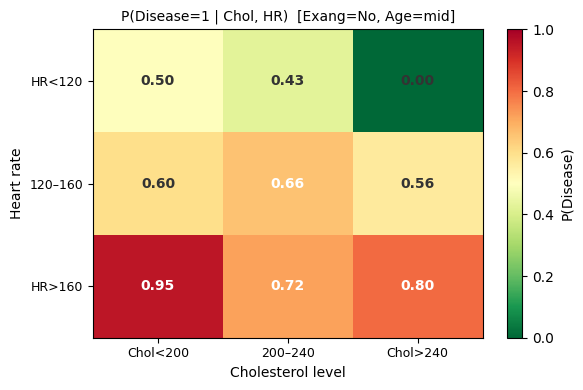

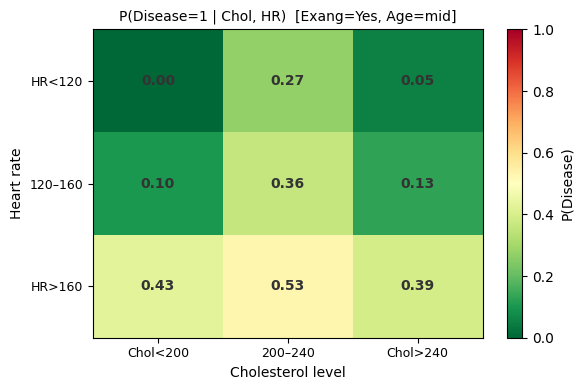

In [78]:
# Posterior heatmap: P(D=1 | Chol, HR)
def posterior_heatmap(I, fix_exang=0, fix_age=1):
    grid = np.zeros((3, 3))
    labels_c = ["Chol<200", "200–240", "Chol>240"]
    labels_h = ["HR<120",   "120–160", "HR>160"]
    for c in range(3):
        for h in range(3):
            ev = {1: c, 4: h, 2: fix_exang, 3: fix_age}
            pd = query_disease(I, ev)
            grid[h, c] = pd["val"][1]  # P(D=1)

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(grid, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(labels_c, fontsize=9)
    ax.set_yticks(range(3)); ax.set_yticklabels(labels_h, fontsize=9)
    ax.set_xlabel("Cholesterol level"); ax.set_ylabel("Heart rate")
    ax.set_title(f"P(Disease=1 | Chol, HR)  [Exang={'Yes' if fix_exang else 'No'}, Age=mid]", fontsize=10)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{grid[i,j]:.2f}", ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if grid[i,j] > 0.6 else "#333")
    plt.colorbar(im, ax=ax, label="P(Disease)")
    plt.tight_layout()
    plt.savefig("posterior_heatmap.png", dpi=150)
    plt.show()

posterior_heatmap(I, fix_exang=0)
posterior_heatmap(I, fix_exang=1)